# Análisis del horizonte de predicción, sensibilidad y patrones de fallo

Este notebook amplía la evaluación de la LSTM realizada en el notebook anterior. Se comparan dos tareas de predicción de PM2.5: una ventana de 24 horas para predecir la hora siguiente (`A_24h_a_1h`) y una ventana de 48 horas para predecir seis horas hacia delante (`B_48h_a_6h`).

La idea es estudiar cómo afecta el horizonte de predicción al rendimiento, comprobar la mejora frente a una línea base naïve, localizar los periodos en los que el modelo comete más errores e identificar situaciones difíciles para la LSTM.

## 1. Entorno y reproducibilidad

Se importan las librerías necesarias y se fija una semilla común para NumPy y PyTorch. Para reproducir la inicialización de la red y el orden aleatorio de los lotes.

In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 8
np.random.seed(SEED)
torch.manual_seed(SEED)
print("torch:", torch.__version__)
print("Semilla fijada:", SEED)

torch: 2.13.0
Semilla fijada: 8


## 2. Protocolo de validación temporal

Se utiliza un hold-out temporal: entrenamiento, validación y prueba se separan respetando el orden cronológico que se utilizó en el notebook anterior. El conjunto de prueba cubre un periodo amplio, por lo que permite evaluar distintos niveles de contaminación sin reentrenar el modelo en múltiples orígenes móviles.

## 3. Datos y configuraciones experimentales

Se cargan los tensores ya preparados y la normalización calculada únicamente con entrenamiento. Se mantienen 11 variables de entrada y se comparan dos configuraciones: 
- `A` con 24 horas de contexto y un horizonte de 1 hora
- `B` con 48 horas de contexto y un horizonte de 6 horas.

La arquitectura y los hiperparámetros se mantienen constantes para atribuir las diferencias principalmente al horizonte de predicción.

In [ ]:
FEATURES = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
            "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
TARGET = "PM2.5"
IDX_TARGET = FEATURES.index(TARGET)

PYTORCH_DIR_PATH = Path("data/pytorch_tensors")
CLEANED_DATA_DIR = Path("data/processed")
RESULTADOS_DIR = Path("results")

train_raw = pd.read_csv(CLEANED_DATA_DIR / "train.csv", parse_dates=["datetime"])
media_pm25 = train_raw["PM2.5"].mean()
desv_pm25 = train_raw["PM2.5"].std()

def desnormalizar(valor_z):
    return valor_z * desv_pm25 + media_pm25

CONFIGURACIONES = {
    "A_24h_a_1h": {"window": 24, "horizon": 1},
    "B_48h_a_6h": {"window": 48, "horizon": 6},
}

tensores = {}
for nombre_config in CONFIGURACIONES:
    tensores[nombre_config] = {}
    for nombre_split in ["train", "val", "test"]:
        d = torch.load(PYTORCH_DIR_PATH / f"{nombre_config}_{nombre_split}.pt")
        tensores[nombre_config][nombre_split] = (d["X"], d["y"])

N_FEATURES = tensores["A_24h_a_1h"]["train"][0].shape[2]

## 4. Arquitectura y función de entrenamiento

Se reutiliza una LSTM de una capa con 64 unidades ocultas. El estado oculto final resume la ventana temporal y una capa lineal produce la predicción de PM2.5. La función de entrenamiento usa Adam, pérdida MSE y parada temprana; además, restaura los pesos correspondientes a la mejor pérdida de validación.

In [ ]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size,
                             num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        return self.fc(h_n[-1]).squeeze(-1)


def entrenar_lstm(X_train, y_train, X_val, y_val, hidden_size,
                   lr=1e-3, batch_size=256, max_epochs=50, patience=5, seed=SEED):
    torch.manual_seed(seed)
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    modelo = LSTMForecaster(n_features=N_FEATURES, hidden_size=hidden_size)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    criterio = nn.MSELoss()

    historial = {"train_loss": [], "val_loss": []}
    mejor_val_loss = float("inf")
    epocas_sin_mejora = 0
    mejor_estado = None

    for epoca in range(1, max_epochs + 1):
        modelo.train()
        perdida_train_total = 0.0
        for X_batch, y_batch in train_loader:
            optimizador.zero_grad()
            pred = modelo(X_batch)
            perdida = criterio(pred, y_batch)
            perdida.backward()
            optimizador.step()
            perdida_train_total += perdida.item() * X_batch.size(0)
        perdida_train = perdida_train_total / len(train_loader.dataset)

        modelo.eval()
        perdida_val_total = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                pred = modelo(X_batch)
                perdida_val_total += criterio(pred, y_batch).item() * X_batch.size(0)
        perdida_val = perdida_val_total / len(val_loader.dataset)

        historial["train_loss"].append(perdida_train)
        historial["val_loss"].append(perdida_val)

        if perdida_val < mejor_val_loss:
            mejor_val_loss = perdida_val
            epocas_sin_mejora = 0
            mejor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            epocas_sin_mejora += 1
            if epocas_sin_mejora >= patience:
                break

    modelo.load_state_dict(mejor_estado)
    return modelo, historial, mejor_val_loss

## 5. Entrenamiento de las dos configuraciones

Se entrenan por separado las configuraciones `A` y `B`, usando la misma arquitectura, tasa de aprendizaje, tamaño de lote y criterio de parada. De este modo, la comparación se centra en el efecto combinado de disponer de una ventana más larga y predecir a un horizonte mayor.

In [ ]:
X_train_A, y_train_A = tensores["A_24h_a_1h"]["train"]
X_val_A, y_val_A = tensores["A_24h_a_1h"]["val"]
X_test_A, y_test_A = tensores["A_24h_a_1h"]["test"]

X_train_B, y_train_B = tensores["B_48h_a_6h"]["train"]
X_val_B, y_val_B = tensores["B_48h_a_6h"]["val"]
X_test_B, y_test_B = tensores["B_48h_a_6h"]["test"]

print("Entrenando LSTM — configuración A (24h->1h)...")
modelo_A, hist_A, val_loss_A = entrenar_lstm(X_train_A, y_train_A, X_val_A, y_val_A, hidden_size=64)
print(f"Config A — mejor val_loss: {val_loss_A:.4f}")

print("\nEntrenando LSTM — configuración B (48h->6h)...")
modelo_B, hist_B, val_loss_B = entrenar_lstm(X_train_B, y_train_B, X_val_B, y_val_B, hidden_size=64)
print(f"Config B — mejor val_loss: {val_loss_B:.4f}")

Entrenando LSTM — configuración A (24h->1h)...
Config A — mejor val_loss: 0.0296

Entrenando LSTM — configuración B (48h->6h)...
Config B — mejor val_loss: 0.1929


## 6. Evaluación en test y comparación con la línea base

Las predicciones se convierten a µg/m³ para calcular RMSE y MAE. Cada LSTM se compara con su línea base naïve utilizando el mismo horizonte de predicción ya que el error tiende a aumentar al predecir más lejos en el tiempo.

In [ ]:
def evaluar_en_test(modelo, X_test, y_test):
    modelo.eval()
    with torch.no_grad():
        pred = modelo(X_test)
    pred_real = desnormalizar(pred)
    y_real = desnormalizar(y_test)
    rmse = torch.sqrt(torch.mean((pred_real - y_real) ** 2)).item()
    mae = torch.mean(torch.abs(pred_real - y_real)).item()
    return rmse, mae, pred_real, y_real

rmse_A, mae_A, pred_test_A, y_test_real_A = evaluar_en_test(modelo_A, X_test_A, y_test_A)
rmse_B, mae_B, pred_test_B, y_test_real_B = evaluar_en_test(modelo_B, X_test_B, y_test_B)

resultados_baseline = pd.read_csv(RESULTADOS_DIR / "resultados_lineas_base.csv")

def baseline_test(config):
    fila = resultados_baseline[
        (resultados_baseline["configuracion"] == config) &
        (resultados_baseline["conjunto"] == "test") &
        (resultados_baseline["linea_base"] == "naive_simple")
    ]
    return fila["RMSE"].values[0], fila["MAE"].values[0]

rmse_base_A, mae_base_A = baseline_test("A_24h_a_1h")
rmse_base_B, mae_base_B = baseline_test("B_48h_a_6h")

tabla_horizonte = pd.DataFrame([
    {"configuracion": "A_24h_a_1h", "modelo": "Naïve simple", "RMSE": rmse_base_A, "MAE": mae_base_A},
    {"configuracion": "A_24h_a_1h", "modelo": "LSTM", "RMSE": round(rmse_A, 2), "MAE": round(mae_A, 2)},
    {"configuracion": "B_48h_a_6h", "modelo": "Naïve simple", "RMSE": rmse_base_B, "MAE": mae_base_B},
    {"configuracion": "B_48h_a_6h", "modelo": "LSTM", "RMSE": round(rmse_B, 2), "MAE": round(mae_B, 2)},
])
print(tabla_horizonte.to_string(index=False))
tabla_horizonte.to_csv(RESULTADOS_DIR / "comparacion_por_horizonte.csv", index=False)

configuracion       modelo  RMSE   MAE
   A_24h_a_1h Naïve simple 22.88 11.45
   A_24h_a_1h         LSTM 20.47 10.60
   B_48h_a_6h Naïve simple 66.14 38.50
   B_48h_a_6h         LSTM 60.37 35.56


## 7. Evolución temporal del error

Se reconstruye la fecha objetivo de cada ventana de prueba y se agrupa el error absoluto por mes. Esta vista permite comprobar si el rendimiento es estable durante todo el periodo o si existen meses con condiciones de contaminación especialmente difíciles para el modelo.

Error absoluto medio por mes (test):
              mean        std  count
mes                                 
2016-09   6.717474   8.389318   8352
2016-10   8.094254  11.417763   8928
2016-11  10.689871  15.165283   8640
2016-12  13.738869  20.610516   8928
2017-01  14.668512  25.557138   8928
2017-02   9.339504  16.134674   8064


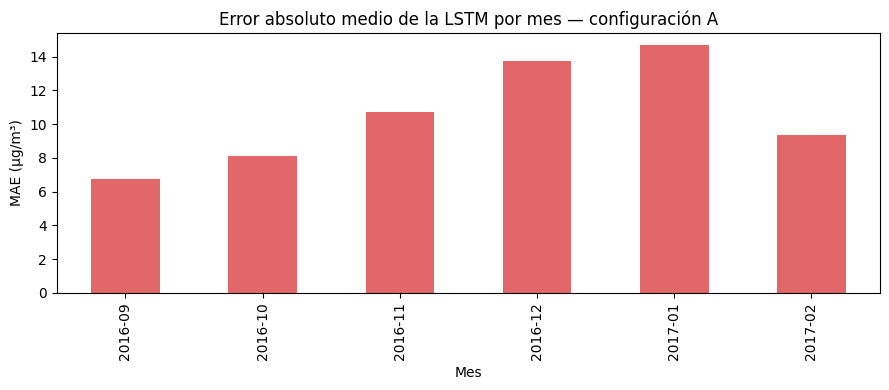

In [ ]:
test_raw = pd.read_csv(CLEANED_DATA_DIR / "test.csv", parse_dates=["datetime"])

fechas_test = []
WINDOW_A, HORIZON_A = 24, 1
for estacion, g in test_raw.groupby("station"):
    g = g.sort_values("datetime").reset_index(drop=True)
    n = len(g)
    for i in range(n - WINDOW_A - HORIZON_A + 1):
        fechas_test.append(g.loc[i + WINDOW_A + HORIZON_A - 1, "datetime"])

fechas_test = pd.Series(fechas_test)
assert len(fechas_test) == len(y_test_real_A), "Desalineación entre fechas y ejemplos de test"

errores_A = (pred_test_A - y_test_real_A).numpy()
df_errores = pd.DataFrame({
    "datetime": fechas_test.values,
    "error_abs": np.abs(errores_A),
    "error": errores_A,
})
df_errores["mes"] = pd.to_datetime(df_errores["datetime"]).dt.to_period("M")

error_por_mes = df_errores.groupby("mes")["error_abs"].agg(["mean", "std", "count"])
print("Error absoluto medio por mes (test):")
print(error_por_mes)

fig, ax = plt.subplots(figsize=(9, 4))
error_por_mes["mean"].plot(kind="bar", ax=ax, color="tab:red", alpha=0.7)
ax.set_ylabel("MAE (µg/m³)")
ax.set_title("Error absoluto medio de la LSTM por mes — configuración A")
ax.set_xlabel("Mes")
plt.tight_layout()
plt.show()

## 8. Identificación de patrones de fallo

Se contrasta la hipótesis de que la LSTM falla más cuando PM2.5 cambia bruscamente entre la última observación y el valor objetivo. La correlación y el diagrama de dispersión relacionan la magnitud del cambio real con el error absoluto y ayudan a distinguir errores asociados a transiciones abruptas.

Correlación entre |cambio real| y error absoluto: 0.865


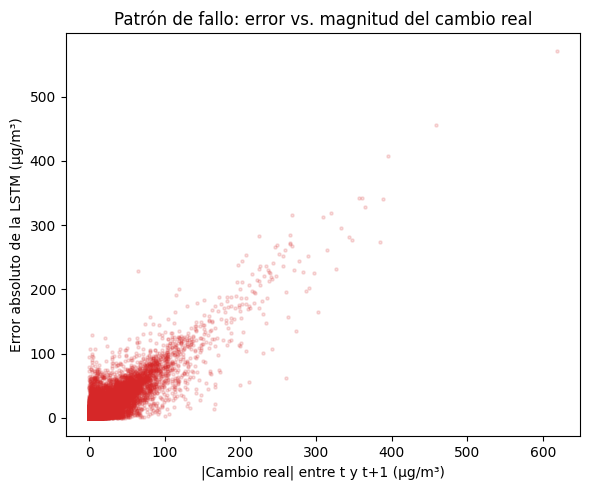

In [ ]:
ultimo_valor_observado = desnormalizar(X_test_A[:, -1, IDX_TARGET])
cambio_real = (y_test_real_A - ultimo_valor_observado).numpy()
error_abs = np.abs(errores_A)

correlacion = np.corrcoef(np.abs(cambio_real), error_abs)[0, 1]
print(f"Correlación entre |cambio real| y error absoluto: {correlacion:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(np.abs(cambio_real), error_abs, s=5, alpha=0.15, color="tab:red")
ax.set_xlabel("|Cambio real| entre t y t+1 (µg/m³)")
ax.set_ylabel("Error absoluto de la LSTM (µg/m³)")
ax.set_title("Patrón de fallo: error vs. magnitud del cambio real")
plt.tight_layout()
plt.show()

## 9. Sensibilidad y resumen de resultados

Se consolidan en una única tabla los experimentos de ventana y horizonte, junto con la comparación entre 32 y 64 unidades ocultas realizada en el notebook anterior. El objetivo es separar el efecto del horizonte de predicción del efecto de aumentar la capacidad de la red.

In [14]:
resumen_sensibilidad = pd.DataFrame([
    {"experimento": "Ventana/horizonte", "variante": "A: 24h->1h", "RMSE_test": round(rmse_A, 2)},
    {"experimento": "Ventana/horizonte", "variante": "B: 48h->6h", "RMSE_test": round(rmse_B, 2)},
    {"experimento": "Hiperparámetro (hidden_size)", "variante": "64 unidades", "RMSE_test": 20.47},
    {"experimento": "Hiperparámetro (hidden_size)", "variante": "32 unidades", "RMSE_test": 20.56},
])
print(resumen_sensibilidad.to_string(index=False))
resumen_sensibilidad.to_csv(RESULTADOS_DIR /"resumen_sensibilidad.csv", index=False)

                 experimento    variante  RMSE_test
           Ventana/horizonte  A: 24h->1h      20.47
           Ventana/horizonte  B: 48h->6h      60.37
Hiperparámetro (hidden_size) 64 unidades      20.47
Hiperparámetro (hidden_size) 32 unidades      20.56


# Conclusiones

- El modelo presenta mayores errores en diciembre y enero, meses en los que también se observan niveles más altos de contaminación. Además, se encontró una correlación de 0.865 entre la magnitud de los cambios de PM2.5 y el error, lo que indica que el modelo tiene mayor dificultad cuando se producen cambios bruscos.

- La capacidad de generalización puede verse limitada porque el modelo fue entrenado con datos de un periodo específico entre 2013 y 2016. Además, disponer de solo cuatro años de información y de algunos datos imputados limita la representación de patrones de largo plazo.

- Como hipótesis de mejora, incorporar variables relacionadas con las condiciones de invierno podría ayudar a reducir los errores observados en este periodo. También se plantea que una función de pérdida más robusta, como Huber Loss, podría mejorar el desempeño ante cambios abruptos de PM2.5.